# Import essential libraries

In [1]:
import pandas as pd              
import numpy as np               
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Import dataset and info of it

In [2]:
data = pd.read_csv('test.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Match Format                 2537 non-null   object
 1   Team1 Name                   2537 non-null   object
 2   Innings1 Team1 Runs Scored   2537 non-null   int64 
 3   Innings1 Team1 Wickets Fell  2537 non-null   int64 
 4   Innings2 Team1 Runs Scored   2537 non-null   int64 
 5   Innings2 Team1 Wickets Fell  2537 non-null   int64 
 6   Team2 Name                   2537 non-null   object
 7   Innings1 Team2 Runs Scored   2537 non-null   int64 
 8   Innings1 Team2 Wickets Fell  2537 non-null   int64 
 9   Innings2 Team2 Runs Scored   2537 non-null   int64 
 10  Innings2 Team2 Wickets Fell  2537 non-null   int64 
 11  Match Venue (Stadium)        2537 non-null   object
 12  Match Venue (Country)        2537 non-null   object
 13  Toss Winner                  2537

# Check whether how many counts of each components in 'Match Format'

In [4]:
choice_counts = data['Match Format'].value_counts()
choice_counts

Match Format
TEST    2537
Name: count, dtype: int64

# Encode table data (teams names)

In [5]:
team_related_cols = ['Team1 Name', 'Team2 Name', 'Toss Winner', 'Match Winner', 'Match Venue (Country)']

# Combine all unique team names + countries (so mapping stays consistent)
unique_teams = pd.unique(data[team_related_cols].values.ravel())
print("✅ Unique team/country names found:\n", unique_teams)

# Fit a single encoder for all team/country names
team_encoder = LabelEncoder()
team_encoder.fit(unique_teams)

# Apply encoding (starting from 1 instead of 0)
for col in team_related_cols:
    data[col] = team_encoder.transform(data[col]) 

# Team name (and country) mapping
team_mapping = {team: code for team, code in zip(team_encoder.classes_, team_encoder.transform(team_encoder.classes_))}
print("\n🏏 Team/Country → Encoded Number Mapping:")
for team, code in team_mapping.items():
    print(f"{team} → {code}")

✅ Unique team/country names found:
 ['Australia' 'New Zealand' 'Zimbabwe' 'Sri Lanka' '0' 'Bangladesh'
 'Pakistan' 'England' 'West Indies' 'India' 'South Africa'
 'United Arab Emirates' 'ICC World XI' 'Ireland' 'Afghanistan']

🏏 Team/Country → Encoded Number Mapping:
0 → 0
Afghanistan → 1
Australia → 2
Bangladesh → 3
England → 4
ICC World XI → 5
India → 6
Ireland → 7
New Zealand → 8
Pakistan → 9
South Africa → 10
Sri Lanka → 11
United Arab Emirates → 12
West Indies → 13
Zimbabwe → 14


# Encode table data (ground)

In [6]:
ground_encoder = LabelEncoder()

data['Match Venue (Stadium)'] = ground_encoder.fit_transform(data['Match Venue (Stadium)'])

# Ground mapping
ground_mapping = {ground: code for ground, code in zip(ground_encoder.classes_, ground_encoder.transform(ground_encoder.classes_))}
print("\n Ground Encoded Number Mapping:")
for ground, code in ground_mapping.items():
    print(f"{ground} → {code}")


 Ground Encoded Number Mapping:
Adelaide Oval → 0
Antigua Recreation Ground → 1
Arbab Niaz Stadium → 2
Arnos Vale Ground → 3
Arun Jaitley Stadium → 4
Asgiriya Stadium → 5
Bagh-e-Jinnah → 6
Bangabandhu National Stadium → 7
Barabati Stadium → 8
Basin Reserve → 9
Bay Oval → 10
Beausejour Stadium → 11
Bellerive Oval → 12
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium → 13
Bir Shrestha Shahid Ruhul Amin Stadium → 14
Bourda → 15
Brabourne Stadium → 16
Bramall Lane → 17
Brisbane Cricket Ground → 18
Buffalo Park → 19
Bulawayo Athletic Club → 20
Bundaberg Rum Stadium → 21
Burlton Park → 22
Carisbrook → 23
Centurion Park → 24
Chittagong Divisional Stadium → 25
Chittagong Stadium → 26
Colombo Cricket Club Ground → 27
Corporation Stadium → 28
Crusaders Ground → 29
Dacca Stadium → 30
Daren Sammy National Cricket Stadium → 31
Darren Sammy National Cricket Stadium → 32
Defence Cricket Stadium → 33
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium → 34
Dring Stadium → 35
Dubai Interna

# Encode table data (match format)

In [7]:
format_mapping = {
    'ODI': 1,
}

data['Match Format'] = data['Match Format'].map(format_mapping)

# Encode table data (toss winner choice)

In [8]:
toss_choice_mapping = {
    'bat': 1,
    'bowl': 2
}

data['Toss Winner Choice'] = data['Toss Winner Choice'].map(toss_choice_mapping)

# Make correation to the identify proper columns

Match Winner                   1.000000
Toss Winner                    0.291814
Match Venue (Country)          0.287847
Team1 Name                     0.270509
Innings2 Team1 Wickets Fell    0.262738
Team2 Name                     0.239351
Innings2 Team2 Wickets Fell    0.231126
Innings1 Team2 Wickets Fell    0.126546
Innings1 Team1 Wickets Fell    0.110682
Innings2 Team2 Runs Scored     0.085871
Toss Winner Choice             0.081245
Match Venue (Stadium)          0.035384
Innings2 Team1 Runs Scored     0.016241
Innings1 Team2 Runs Scored    -0.079383
Innings1 Team1 Runs Scored    -0.187832
Match Format                        NaN
Name: Match Winner, dtype: float64


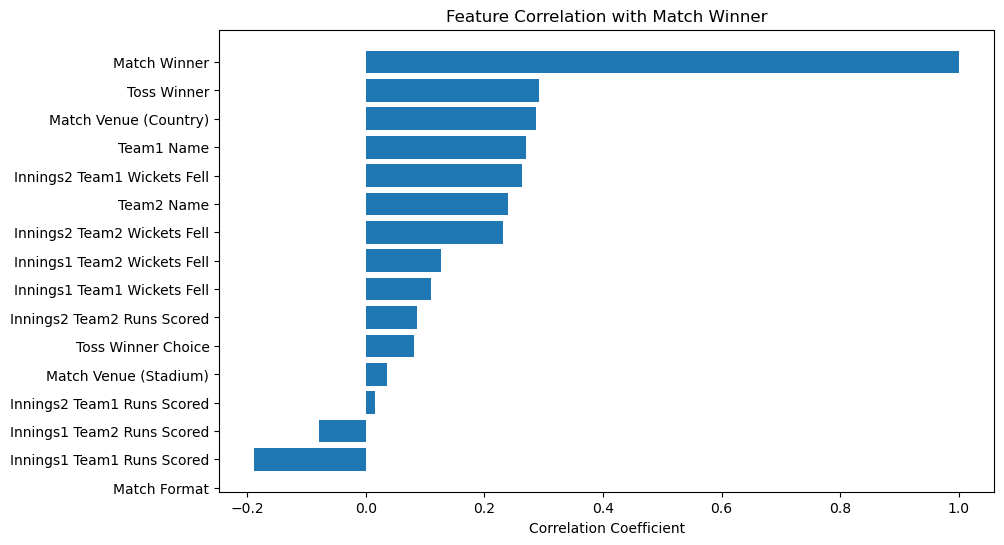

In [9]:
import matplotlib.pyplot as plt

correlation = data.corr(numeric_only=True)['Match Winner'].sort_values(ascending=False)
print(correlation)

# Plot using matplotlib only
plt.figure(figsize=(10,6))
plt.barh(correlation.index, correlation.values)
plt.title("Feature Correlation with Match Winner")
plt.xlabel("Correlation Coefficient")
plt.gca().invert_yaxis() 
plt.show()

# Drop low-correlation columns

In [10]:
columns_to_drop = [
    'Match Venue (Stadium)',
    'Toss Winner Choice',
    'Match Format',
    'Innings2 Team1 Wickets Fell',
    'Innings2 Team2 Wickets Fell',
    'Innings1 Team2 Wickets Fell',
    'Innings1 Team1 Wickets Fell',
    'Innings2 Team2 Runs Scored',
    'Toss Winner Choice',
    'Match Venue (Stadium)',
    'Innings2 Team1 Runs Scored',
    'Innings1 Team2 Runs Scored',
    'Innings1 Team1 Runs Scored'
]

data = data.drop(columns=columns_to_drop, axis=1)

# Check the remaining columns
data.columns

Index(['Team1 Name', 'Team2 Name', 'Match Venue (Country)', 'Toss Winner',
       'Match Winner'],
      dtype='object')

# Separate features (X) and target (y)

In [11]:
X = data.drop(['Match Winner'], axis=1)
y = data['Match Winner']

# Train and test dataset

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Create model dictionary to find the best model

In [34]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# train each models
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = {'Accuracy': acc, 'F1 Score': f1}

# Show comparison
results_df = pd.DataFrame(results).T
results_df.sort_values(by='Accuracy', ascending=False)

,Accuracy,F1 Score
Gradient Boosting,0.488189,0.483824
Random Forest,0.448819,0.448554
SVM,0.388976,0.271119
Logistic Regression,0.362205,0.250627


# Select the best model

In [35]:
gradient_boost_model = models['Gradient Boosting']

# Try example encoded user input

In [38]:
new_match = {
    'Team1 Name': 4,   
    'Team2 Name': 12,  
    'Match Venue (Country)': 4,  
    'Toss Winner': 4   
}

# Convert to DataFrame
new_df = pd.DataFrame([new_match])

# Get the mean values for runs scored, wickets fell for each teams using stats by handle NaN values using Global averages
team1 = new_match['Team1 Name']
team2 = new_match['Team2 Name']

# Prediction Probabilities

In [39]:
try:
    probabilities = gradient_boost_model.predict_proba(new_df)[0]
    classes = gradient_boost_model.classes_

    # Initialize default values
    team1_prob = team2_prob = tie_prob = 0.0

    for cls, prob in zip(classes, probabilities):
        if cls == team1:
            team1_prob = prob * 100
        elif cls == team2:
            team2_prob = prob * 100
        elif cls == 0:
            tie_prob = prob * 100  # 0 means tie/no result

    
    # Normalize (if tie/no result small, adjust for 100%)
    total = team1_prob + team2_prob + tie_prob
    if total > 0:
        team1_prob = round((team1_prob / total) * 100, 2)
        team2_prob = round((team2_prob / total) * 100, 2)
        tie_prob = round((tie_prob / total) * 100, 2)

    print("\n🏏 Predicted Winning Probabilities:")
    print(f"Team1 (Encoded {team1}) Winning Chance: {team1_prob}%")
    print(f"Team2 (Encoded {team2}) Winning Chance: {team2_prob}%")
    print(f"Tie/No Result Chance: {tie_prob}%")

except Exception as e:
    print(f"\n❌ Prediction failed: {e}")


🏏 Predicted Winning Probabilities:
Team1 (Encoded 4) Winning Chance: 59.73%
Team2 (Encoded 12) Winning Chance: 0.0%
Tie/No Result Chance: 40.27%
